In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [2]:
DATA_PATH = '../data/processed/diabetes_processed.csv' 
SCALER_PATH = '../output/diabetes_rf_scaler.joblib'
MODEL_SAVE_PATH = '../output/diabetes_cluster_model.joblib'

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
X = df.drop(columns=['Outcome'])

In [5]:
scaler = joblib.load(SCALER_PATH)

In [6]:
X_scaled = scaler.transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(f"Data shape for clustering: {X_scaled.shape}")

Data shape for clustering: (768, 8)


In [7]:
inertia = []
silhouette_scores = []
K_range = range(2, 8)

In [8]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, kmeans.labels_))

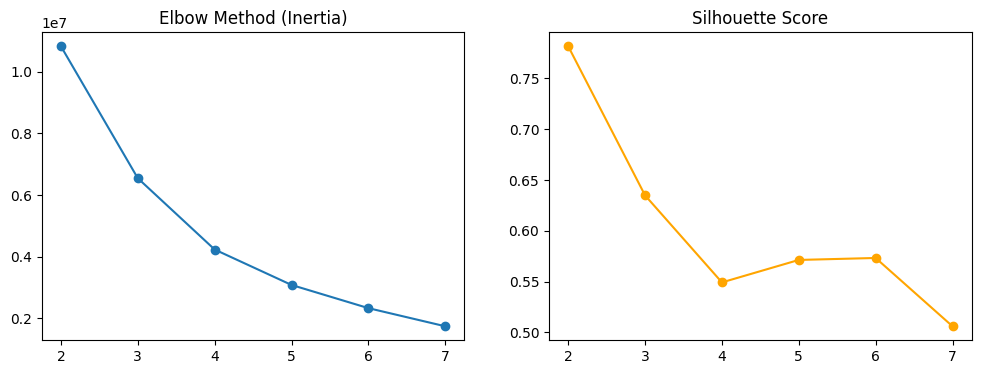

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia, marker='o')
axes[0].set_title('Elbow Method (Inertia)')
axes[1].plot(K_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
plt.show()

In [10]:
OPTIMAL_K = 3 
final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['Cluster'] = final_kmeans.fit_predict(X_scaled_df)

In [11]:
cluster_centroids = df.groupby('Cluster').mean()
print("\n--- Cluster Centroids (Mean Feature Values per Cluster) ---")
display(cluster_centroids)


--- Cluster Centroids (Mean Feature Values per Cluster) ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Cluster,,,,,,,,,
0,3.690000,138.950000,73.720000,31.460000,234.170000,35.159000,0.579840,34.280000,0.510000
1,3.886822,117.455814,72.249612,28.617054,112.820155,31.929147,0.449733,33.088372,0.316279
2,3.347826,164.260870,70.434783,32.652174,515.217391,35.452174,0.623435,33.000000,0.565217


In [12]:
joblib.dump(final_kmeans, MODEL_SAVE_PATH)

['../output/diabetes_cluster_model.joblib']